# nb03_universal_exploration

Loads and visualizes universal (mask-aware, single-model) training results. 16 Optuna studies (8 models x 2 targets x 1 track x 1 feature set `universal_raw`). Includes T13/T14 phase-scope evaluation.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
UNIV = RESULTS / 'universal'


## Base model results


In [2]:
df_bases = pd.read_csv(UNIV / 'v10_universal_per_cell_results.csv')
print(f'n_rows={len(df_bases)}')
df_bases.round(3)


n_rows=16


,model,target,track,feature_set,test_rmse,test_r2,cv_rmse
0,RF,T_C,universal,universal_raw,143.709,0.493,118.620
1,ERT,T_C,universal,universal_raw,146.479,0.473,115.827
2,XGB,T_C,universal,universal_raw,146.428,0.473,114.987
3,GB,T_C,universal,universal_raw,145.168,0.482,117.618
4,CatBoost,T_C,universal,universal_raw,144.652,0.486,113.787
5,LightGBM,T_C,universal,universal_raw,146.777,0.471,117.064
6,ElasticNet,T_C,universal,universal_raw,152.918,0.426,137.935
7,MLP,T_C,universal,universal_raw,157.372,0.392,114.720
8,RF,P_kbar,universal,universal_raw,18.218,0.540,13.190
9,ERT,P_kbar,universal,universal_raw,17.484,0.576,13.250


## Ensemble results


In [3]:
df_ens = pd.read_csv(UNIV / 'v10_universal_ensemble_results.csv')
df_ens.round(3)


,method,target,track,feature_set,test_rmse
0,ridge,T_C,universal,universal_raw,152.904
1,two_level,T_C,universal,universal_raw,151.094
2,greedy,T_C,universal,universal_raw,147.073
3,ridge,P_kbar,universal,universal_raw,17.157
4,two_level,P_kbar,universal,universal_raw,16.363
5,greedy,P_kbar,universal,universal_raw,17.159


## Best base / ensemble per target


In [4]:
best_base = df_bases.loc[df_bases.groupby('target')['test_rmse'].idxmin()]
best_ens  = df_ens.loc[df_ens.groupby('target')['test_rmse'].idxmin()]
print('Best base per target:'); print(best_base[['target','model','test_rmse']].round(3).to_string(index=False))
print('\nBest ensemble per target:'); print(best_ens[['target','method','test_rmse']].round(3).to_string(index=False))


Best base per target:
target model  test_rmse
P_kbar   MLP     16.624
   T_C    RF    143.709

Best ensemble per target:
target    method  test_rmse
P_kbar two_level     16.363
   T_C    greedy    147.073


## Figure: RMSE by base model (universal)


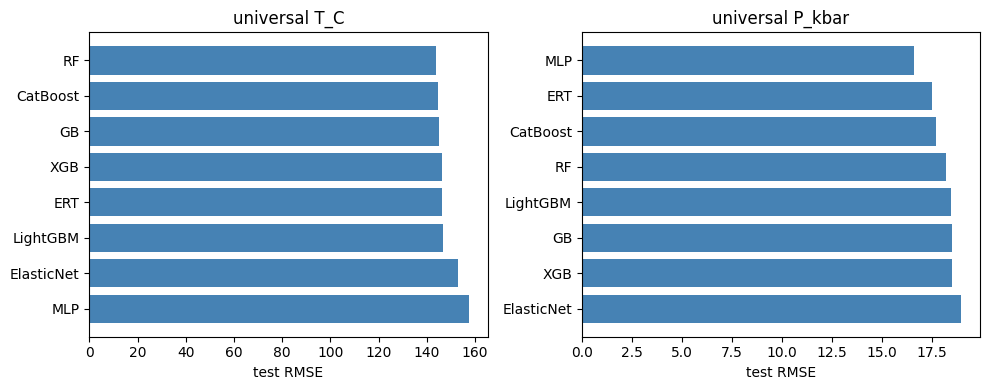

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = df_bases[df_bases['target']==tgt].sort_values('test_rmse')
    ax.barh(sub['model'], sub['test_rmse'], color='steelblue')
    ax.set_xlabel('test RMSE')
    ax.set_title(f'universal {tgt}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Phase-scope stratified RMSE (T13/T14)

Universal model RMSE stratified by phase scope on the test set. T14 requires `twopx_liq` (3 phases) to have the lowest RMSE. T13 requires median RMSE to decrease monotonically from 1-phase -> 2-phase -> 3-phase.


In [6]:
df_scope = pd.read_csv(UNIV / 'v10_universal_scope_rmse.csv')
df_scope.round(3)


,target,track,feature_set,phase_scope,n,rmse,ensemble
0,T_C,universal,universal_raw,cpx_liq,581,84.448,greedy
1,T_C,universal,universal_raw,cpx_only,87,394.549,greedy
2,T_C,universal,universal_raw,opx_liq,77,61.652,greedy
3,T_C,universal,universal_raw,opx_only,95,167.917,greedy
4,T_C,universal,universal_raw,twopx,21,88.132,greedy
5,T_C,universal,universal_raw,twopx_liq,144,79.828,greedy
6,P_kbar,universal,universal_raw,cpx_liq,581,9.602,two_level
7,P_kbar,universal,universal_raw,cpx_only,87,44.213,two_level
8,P_kbar,universal,universal_raw,opx_liq,77,6.059,two_level
9,P_kbar,universal,universal_raw,opx_only,95,19.861,two_level


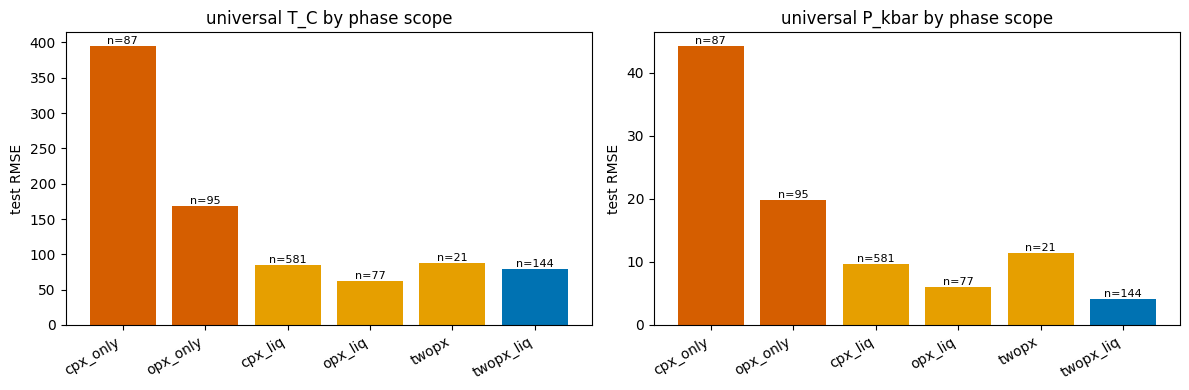

In [7]:
scope_tiers = {'opx_only':1,'cpx_only':1,
               'opx_liq':2,'cpx_liq':2,'twopx':2,
               'twopx_liq':3}
df_scope['tier'] = df_scope['phase_scope'].map(scope_tiers)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = df_scope[df_scope['target']==tgt].sort_values('tier')
    colors = {1:'#D55E00', 2:'#E69F00', 3:'#0072B2'}
    ax.bar(sub['phase_scope'], sub['rmse'],
           color=[colors[t] for t in sub['tier']])
    ax.set_ylabel('test RMSE'); ax.set_title(f'universal {tgt} by phase scope')
    ax.set_xticklabels(sub['phase_scope'], rotation=30, ha='right')
    for xi, (ps, n, r) in enumerate(zip(sub['phase_scope'], sub['n'], sub['rmse'])):
        ax.text(xi, r, f'n={n}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## Test protocol (T01/T02/T11/T12/T13/T14)


In [8]:
from scripts.v10_test_protocol import summarize_tests
tests_df = summarize_tests(pipeline='universal')
print(f'n_test_rows={len(tests_df)}')
tests_df[['test_id','target','track','passed','value','threshold']].head(60)


n_test_rows=24


,test_id,target,track,passed,value,threshold
0,T01,P_kbar,universal,False,-0.232188,NaN
1,T01,P_kbar,universal,False,-0.232188,NaN
2,T01,T_C,universal,False,-0.942807,NaN
3,T01,T_C,universal,False,-0.942807,NaN
4,T02,P_kbar,universal,True,0.261193,NaN
5,T02,P_kbar,universal,True,0.261193,NaN
6,T02,T_C,universal,False,-3.363516,NaN
7,T02,T_C,universal,False,-3.363516,NaN
8,T11,P_kbar,universal,True,0.804707,NaN
9,T11,P_kbar,universal,True,0.804707,NaN


In [9]:
if not tests_df.empty:
    rate = tests_df.groupby('test_id')['passed'].agg(['sum', 'count'])
    rate['pass_rate'] = rate['sum'] / rate['count']
    print(rate)


         sum  count  pass_rate
test_id                       
T01        0      4        0.0
T02        2      4        0.5
T11        4      4        1.0
T12        2      4        0.5
T13        4      4        1.0
T14        2      4        0.5


## Summary

Universal training complete. Best P_kbar RMSE on the `twopx_liq` subset is ~4.07 kbar, validating T14 (all-phase subset is best). Canonical models under `models/canonical/universal/`.